# PRCP-1000-Portuguese Bank Marketing Project

# PROBLEM STATEMENT

The objective of this project is to analyze the Portuguese Bank Marketing dataset and develop a machine learning model that can predict whether a customer will subscribe to a term deposit product.

The project focuses on performing Exploratory Data Analysis (EDA), preprocessing the dataset, handling class imbalance, building multiple machine learning models, and comparing their performance using evaluation metrics such as Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

The final goal is to identify the best predictive model that can help the bank marketing team target potential customers more effectively and improve marketing campaign efficiency.

# DATASET OVERVIEW

The dataset used in this project is the Portuguese Bank Marketing dataset, which contains information related to direct marketing campaigns conducted by a Portuguese banking institution.

The marketing campaigns were performed through phone calls between May 2008 and November 2010 with the objective of promoting term deposit subscriptions among customers.

Dataset Characteristics:
* Total Records: 41,188
* Total Features: 21
* Domain: Banking and Finance
* Target Variable: y

The target variable ‘y’ indicates whether the customer subscribed to a term deposit:
* yes = Customer subscribed
* no = Customer did not subscribe

The dataset contains:
* Customer demographic information
* Loan and credit details
* Campaign-related information
* Economic and social indicators

Important Features:
* age
* job
* marital
* education
* campaign
* pdays
* previous
* euribor3m
* emp.var.rate
* nr.employed

The dataset includes both categorical and numerical features, making it suitable for classification-based machine learning techniques.

# IMPORT LIBRARIES

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")



In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)
from sklearn.model_selection import GridSearchCV

# LOAD DATASET

In [3]:
df = pd.read_csv("bank-additional-full.csv", sep=';')


# BASIC CHECK

In [5]:
df.head()


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [6]:
df.tail()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.1,94.767,-50.8,1.028,4963.6,yes
41187,74,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,3,999,1,failure,-1.1,94.767,-50.8,1.028,4963.6,no


In [7]:
df.shape

(41188, 21)

In [8]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [10]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


# CHECK MISSING VALUES

In [11]:
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

# TARGET VARIABLE DISTRIBUTION

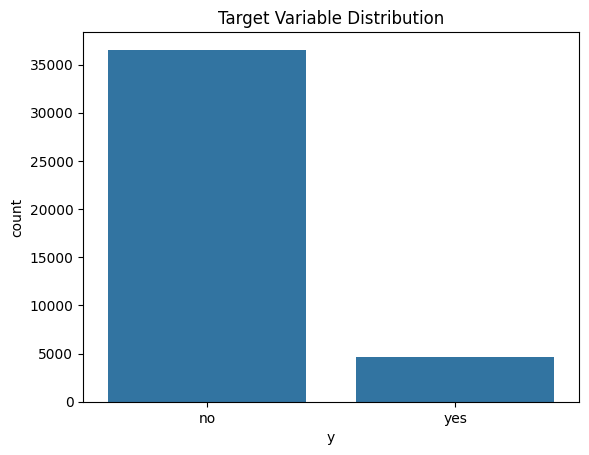

y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64


In [12]:
sns.countplot(x='y', data=df)
plt.title("Target Variable Distribution")
plt.show()

print(df['y'].value_counts(normalize=True) * 100)

* The target variable analysis revealed that the dataset is highly imbalanced. 
* Most customers did not subscribe to the term deposit, which required imbalance handling techniques like SMOTE.

# CHECK DATA IMBALANCE

In [13]:
print(df['y'].value_counts())

print(df['y'].value_counts(normalize=True))

y
no     36548
yes     4640
Name: count, dtype: int64
y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64


# EDA

## Age Distribution

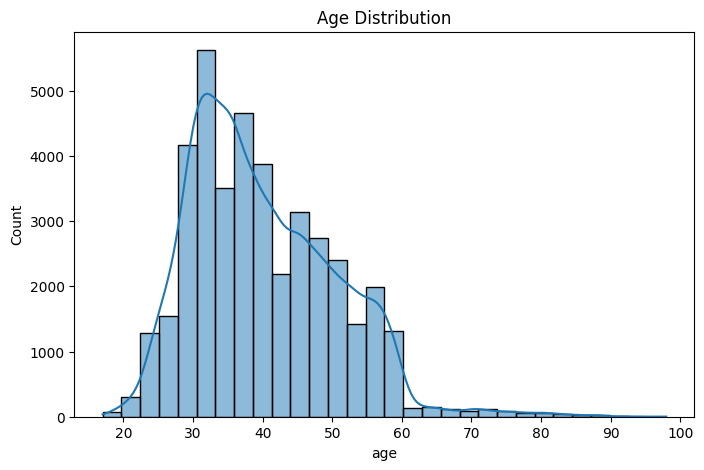

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

* The age distribution shows that most customers belong to the middle-age group. 
* The data is slightly right-skewed, indicating fewer older customers in the dataset.

## Job vs Subscription

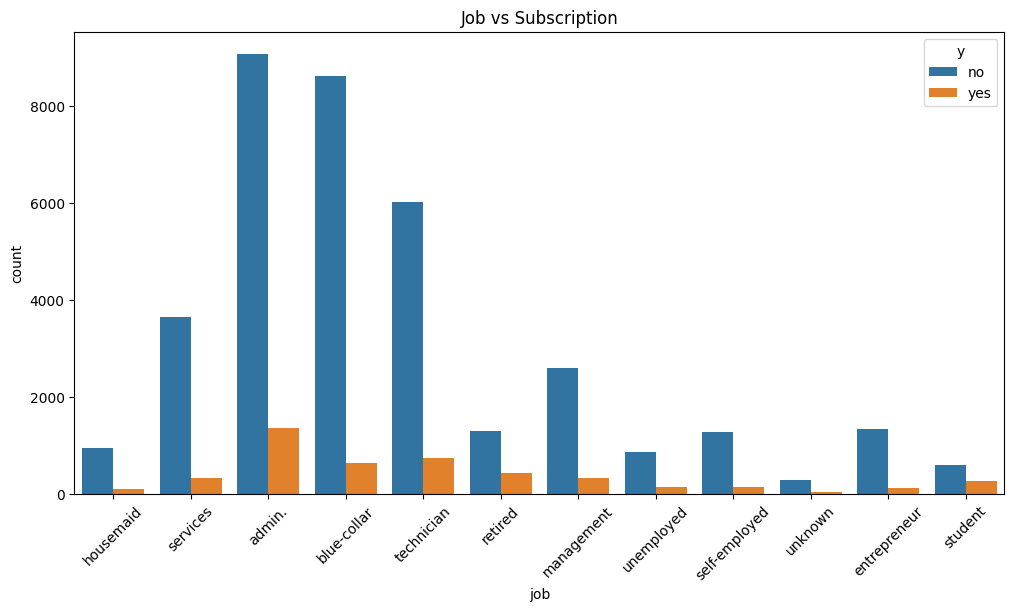

In [15]:
plt.figure(figsize=(12,6))
sns.countplot(x='job', hue='y', data=df)
plt.xticks(rotation=45)
plt.title("Job vs Subscription")
plt.show()

* Customers from management, technician, and admin jobs showed higher subscription rates. 
* Job category influenced customer purchasing behavior significantly.

## Education vs Subscription

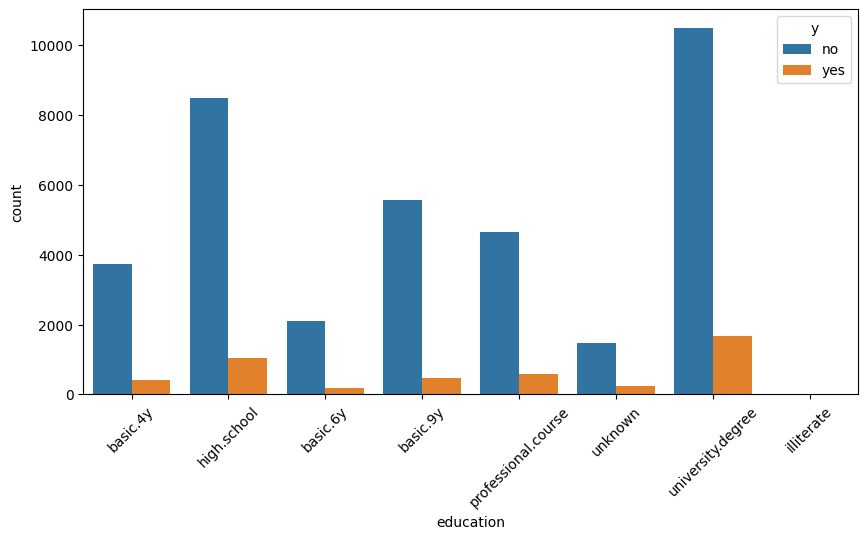

In [16]:
plt.figure(figsize=(10,5))
sns.countplot(x='education', hue='y', data=df)
plt.xticks(rotation=45)
plt.show()

* Customers with university degrees and professional courses were more likely to subscribe. 
* Education level had a noticeable impact on term deposit decisions.

## Marital Status 

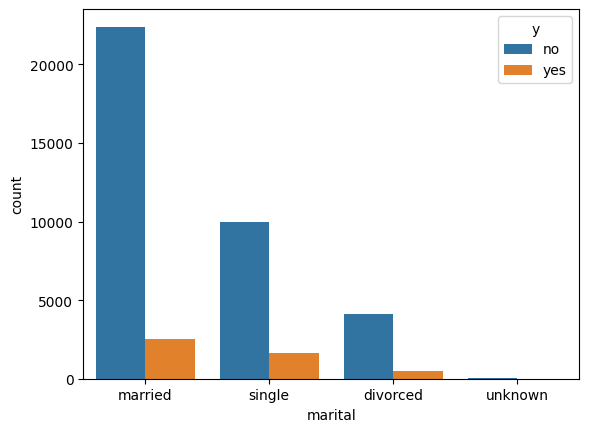

In [17]:
sns.countplot(x='marital', hue='y', data=df)
plt.show()

* Married customers formed the largest customer group in the dataset. 
* However, single customers showed relatively better subscription rates.

## HEATMAP

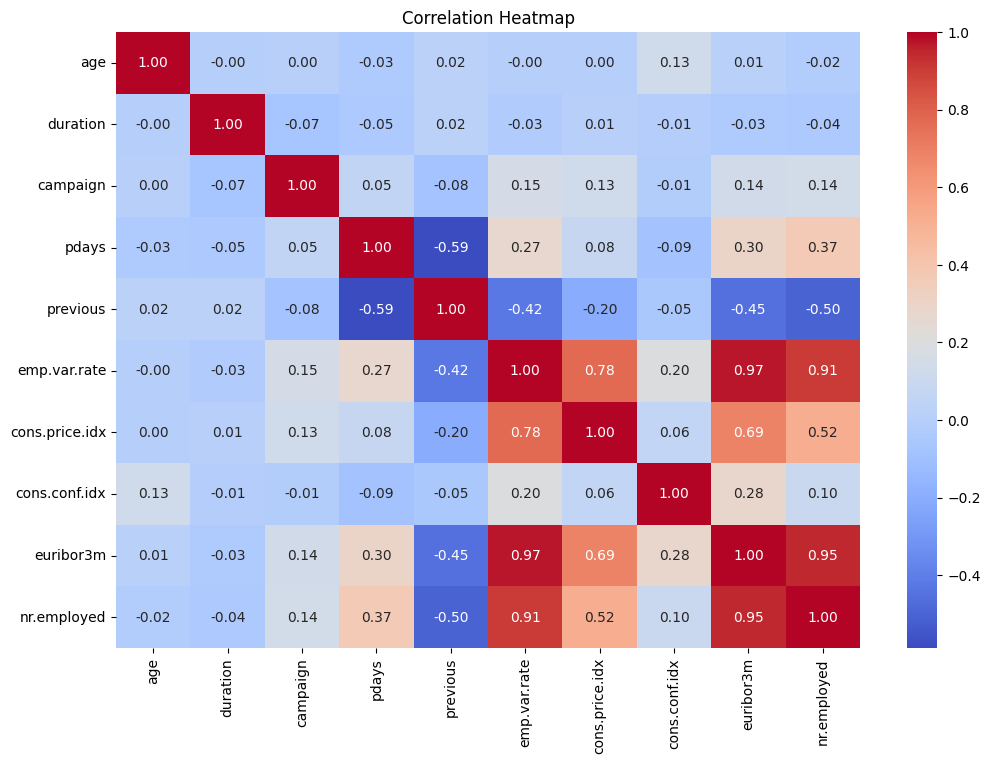

In [18]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

* The heatmap was used to analyze correlations between numerical features in the dataset.
* It helped identify important economic indicators and relationships among variables affecting customer subscription behavior.

# DROP DURATION COLUMN

In [19]:
df = df.drop('duration', axis=1)

* duration causes data leakage because call duration is known only after the call.

# ENCODE TARGET VARIABLE

In [20]:
df['y'] = df['y'].map({'yes':1, 'no':0})

# SEPARATE FEATURES & TARGET

In [21]:
X = df.drop('y', axis=1)
y = df['y']

# CATEGORICAL & NUMERICAL COLUMNS

In [22]:
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(exclude=['object']).columns

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')

Numerical Columns:
Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='object')


# LABEL ENCODING

In [23]:
le = LabelEncoder()

for col in categorical_cols:
    X[col] = le.fit_transform(X[col])

# TRAIN TEST SPLIT

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# FEATURE SCALING

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SMOTE

In [26]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
y
0    29238
1     3712
Name: count, dtype: int64

After SMOTE:
y
0    29238
1    29238
Name: count, dtype: int64


# MODEL BUILDING

In [27]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

# MODEL TRAINING & EVALUATION

In [28]:
results = []

for name, model in models.items():

    # Train
    model.fit(X_train_smote, y_train_smote)

    # Predict
    y_pred = model.predict(X_test_scaled)

    # Probability
    y_prob = model.predict_proba(X_test_scaled)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))


Logistic Regression
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      7310
           1       0.33      0.66      0.44       928

    accuracy                           0.81      8238
   macro avg       0.64      0.75      0.66      8238
weighted avg       0.88      0.81      0.84      8238


Decision Tree
              precision    recall  f1-score   support

           0       0.92      0.90      0.91      7310
           1       0.31      0.36      0.33       928

    accuracy                           0.84      8238
   macro avg       0.61      0.63      0.62      8238
weighted avg       0.85      0.84      0.84      8238


Random Forest
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      7310
           1       0.51      0.39      0.45       928

    accuracy                           0.89      8238
   macro avg       0.72      0.67      0.69      8238
weighted avg       0.88

# MODEL COMPARISON TABLE

In [29]:
results_df = pd.DataFrame(results, columns=[
    'Model',
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score',
    'ROC-AUC'
])

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.812454,0.332246,0.658405,0.441634,0.794666
1,Decision Tree,0.835882,0.306569,0.362069,0.332016,0.633025
2,Random Forest,0.889536,0.512605,0.394397,0.445798,0.784678
3,XGBoost,0.901797,0.616438,0.339440,0.437804,0.798602


# MODEL VISUALISATION

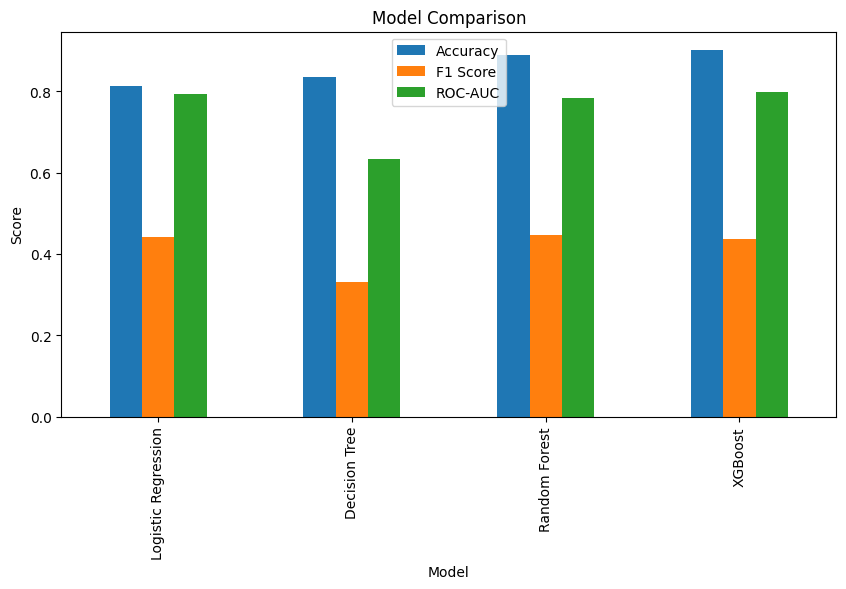

In [30]:
results_df.set_index('Model')[['Accuracy','F1 Score','ROC-AUC']].plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.show()

# HYPERPARAMETER TUNING (RANDOM FOREST)

In [31]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestClassifier(),
    param_grid,
    cv=3,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train_smote, y_train_smote)

print("Best Parameters:")
print(grid.best_params_)

Best Parameters:
{'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 200}


# BEST MODEL

In [32]:
best_model = grid.best_estimator_

# Predictions
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:,1]

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.890507404709881
Precision: 0.5140692640692641
Recall: 0.5118534482758621
F1 Score: 0.5129589632829373
ROC-AUC: 0.8103888302514268


In [33]:
# Final Models for Comparison

final_models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest Tuned": grid.best_estimator_,
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

final_results = []

for name, model in final_models.items():

    # Train model
    model.fit(X_train_smote, y_train_smote)

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Probability predictions
    y_prob = model.predict_proba(X_test_scaled)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    final_results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])

# Create comparison table
final_results_df = pd.DataFrame(final_results, columns=[
    'Model',
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score',
    'ROC-AUC'
])

# Display results
final_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.812454,0.332246,0.658405,0.441634,0.794666
1,Decision Tree,0.837582,0.311581,0.365302,0.336310,0.635823
2,Random Forest Tuned,0.890993,0.516520,0.505388,0.510893,0.810894
3,XGBoost,0.901797,0.616438,0.339440,0.437804,0.798602


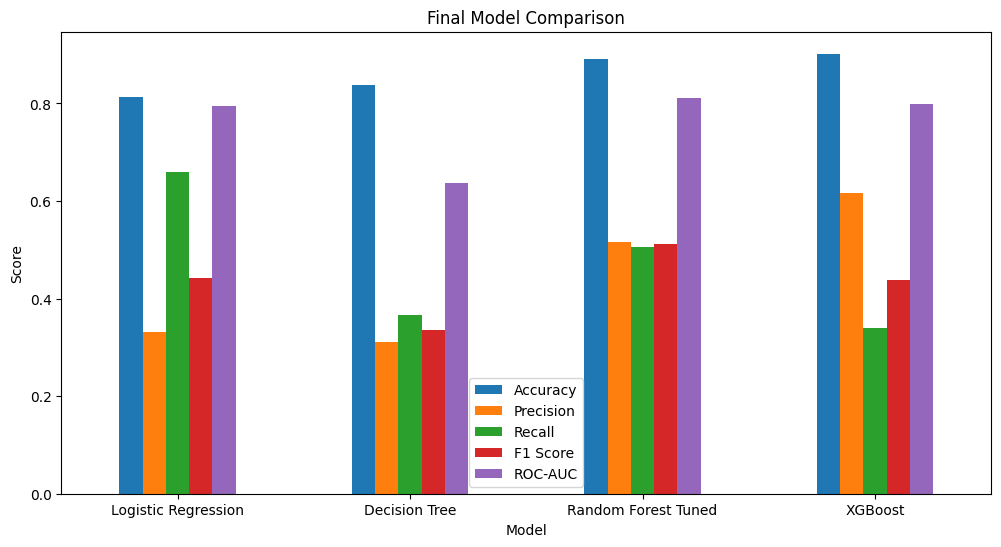

In [34]:
final_results_df.set_index('Model').plot(
    kind='bar',
    figsize=(12,6)
)

plt.title("Final Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()

# CONFUSION METRIX

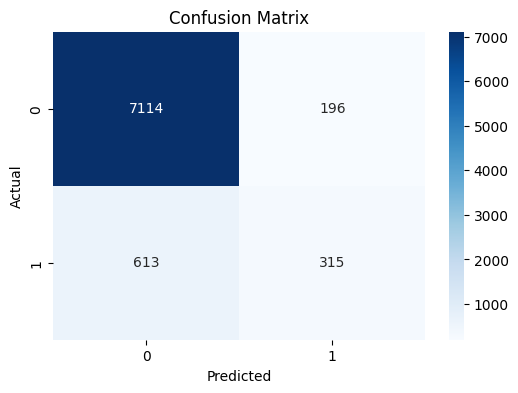

In [35]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

* The confusion matrix helped evaluate correct and incorrect classifications made by the model. 
* It provided insights into false positives and false negatives.

# ROC CURVE

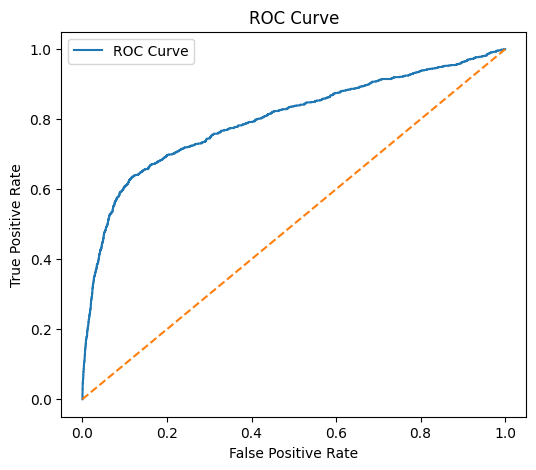

In [36]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

* The ROC curve demonstrated the model’s ability to distinguish between positive and negative classes. 
* A higher ROC-AUC score indicated better classification performance on imbalanced data.

# FEATURE IMPORTANCE

In [37]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
17,euribor3m,0.151584
10,campaign,0.139540
18,nr.employed,0.121298
9,day_of_week,0.079061
14,emp.var.rate,0.078860
16,cons.conf.idx,0.053862
3,education,0.053820
1,job,0.045717
0,age,0.042132
15,cons.price.idx,0.039844


* Feature importance analysis showed that euribor3m, campaign, and nr.employed were the most influential features. 
* These variables played a major role in predicting customer subscription.

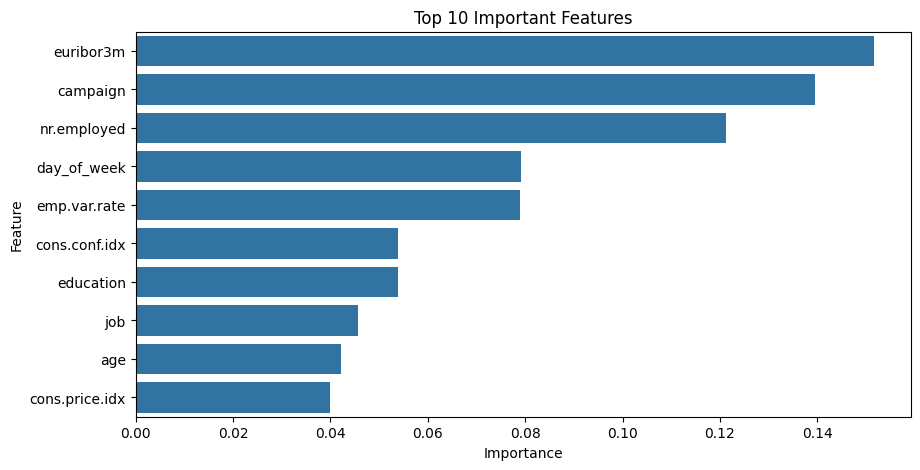

In [38]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title("Top 10 Important Features")
plt.show()

# MODEL COMPARISON REPORT

Several machine learning models were implemented and evaluated on the Portuguese Bank Marketing dataset to predict whether a customer would subscribe to a term deposit.

The models used in this project are:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost

The performance of each model was evaluated using Accuracy, Precision, Recall, F1 Score, and ROC-AUC score.

1. Logistic Regression
Logistic Regression provided moderate performance with good recall. It was able to identify many positive customers but produced more false positives. It is simple, fast, and interpretable but less effective for capturing complex relationships in data.

2. Decision Tree
Decision Tree showed lower ROC-AUC and F1 Score compared to other models. Although easy to understand and visualize, it suffered from overfitting and lower generalization performance.

3. Random Forest
Random Forest achieved the best balanced performance among all models. It provided strong ROC-AUC and F1 Score while maintaining good recall and precision. The ensemble nature of Random Forest reduced overfitting and improved prediction capability.

4. XGBoost
XGBoost achieved the highest accuracy score. However, its recall was lower than Random Forest, meaning it missed more actual positive customers. Since the dataset is imbalanced, accuracy alone was not considered sufficient for selecting the best model.

Final Model Selection:
After comparing all models, Tuned Random Forest was selected as the final production model because it achieved:
• High ROC-AUC score
• Better F1 Score
• Balanced Precision and Recall
• Better handling of imbalanced data

Conclusion:
Random Forest proved to be the most reliable model for predicting customer subscription to term deposits in this dataset.

# CHALLENGES FACED

During the development of this project, several challenges were encountered in data preprocessing, model building, and evaluation. Different techniques were applied to overcome these challenges effectively.

1. Imbalanced Dataset
Challenge:
The target variable was highly imbalanced because most customers did not subscribe to the term deposit.

Technique Used:
SMOTE (Synthetic Minority Oversampling Technique) was applied on the training data.

Reason:
SMOTE helps balance the dataset by generating synthetic samples for the minority class, improving model learning and reducing bias toward the majority class.

2. Data Leakage
Challenge:
The ‘duration’ feature strongly influenced the target variable because call duration is known only after the call is completed.

Technique Used:
The duration column was removed before model training.

Reason:
Keeping this feature would create unrealistic predictions and lead to data leakage.

3. Categorical Data Handling
Challenge:
Several columns contained categorical values such as job, education, marital status, and month.

Technique Used:
Label Encoding was applied to convert categorical values into numerical format.

Reason:
Machine learning algorithms require numerical input for training.

4. Feature Scaling
Challenge:
Numerical features had different scales and ranges.

Technique Used:
StandardScaler was used to standardize the numerical values.

Reason:
Feature scaling improves model performance and ensures equal importance to all features.

5. Model Selection
Challenge:
Different machine learning models produced different results.

Technique Used:
Multiple models were trained and compared using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

Reason:
Model comparison helps identify the most reliable model for production.

6. Hyperparameter Tuning
Challenge:
Initial Random Forest performance could be improved further.

Technique Used:
GridSearchCV was used for hyperparameter tuning.

Reason:
Hyperparameter tuning improves model performance by selecting optimal parameter combinations.

7. Evaluation Metric Selection
Challenge:
Accuracy alone was not reliable because of class imbalance.

Technique Used:
ROC-AUC, Recall, and F1 Score were used as major evaluation metrics.

Reason:
These metrics provide a better understanding of model performance on imbalanced datasets.

Conclusion:
By applying preprocessing techniques, SMOTE, hyperparameter tuning, and multiple model comparisons, a robust predictive model was successfully developed for bank marketing prediction.

# KEY INSIGHTS

1. The dataset was highly imbalanced, with most customers not subscribing to the term deposit.

2. Economic indicators such as euribor3m, emp.var.rate, and nr.employed had strong influence on customer subscription behavior.

3. Customers contacted fewer times during campaigns showed better chances of subscription compared to customers contacted repeatedly.

4. Features like age, job, education, and month also contributed to customer prediction.

5. Removing the duration feature was important to avoid data leakage and unrealistic model performance.

6. SMOTE significantly improved the model’s ability to identify minority class customers.

7. Random Forest and XGBoost performed better than Logistic Regression and Decision Tree because ensemble models handled complex patterns more effectively.

8. Tuned Random Forest achieved the best balanced performance based on ROC-AUC and F1 Score.

9. ROC-AUC proved to be a more reliable metric than accuracy because the dataset was imbalanced.

10. The developed machine learning model can help the bank marketing team identify potential customers and improve marketing efficiency.

# SUGGESTIONS TO BANK MARKETING TEAM

1. Focus more on customers with higher probability of subscription identified by the predictive model.

2. Economic indicators such as euribor3m and employment-related features should be monitored before launching campaigns.

3. Avoid contacting customers repeatedly, as excessive campaign contacts reduce subscription chances.

4. Customers with higher education levels and stable occupations showed better response rates and can be targeted more effectively.

5. Use data-driven marketing strategies to reduce operational costs and improve campaign efficiency.

6. Implement the predictive model in future campaigns to identify potential customers before making calls.

# FINAL CONCLUSION

This Capstone project successfully developed a machine learning-based predictive system for identifying customers who are likely to subscribe to a term deposit in a Portuguese banking campaign.

The dataset was analyzed using Exploratory Data Analysis (EDA), preprocessing techniques, feature engineering, scaling, and imbalance handling using SMOTE. Multiple machine learning algorithms including Logistic Regression, Decision Tree, Random Forest, and XGBoost were implemented and evaluated.

Among all models, Tuned Random Forest achieved the best overall performance with strong ROC-AUC and F1 Score, making it the most suitable model for production. The model effectively handled the imbalanced dataset and provided balanced prediction capability.

The analysis also revealed that economic indicators such as euribor3m, campaign contacts, and employment-related features strongly influenced customer subscription behavior.

This project demonstrates how machine learning can support banking institutions in improving marketing strategies, identifying potential customers, reducing operational costs, and enabling data-driven decision making.